<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br><br><br>

# Listed Volatility and Variance Derivatives

**Wiley Finance (2017)**

Dr. Yves J. Hilpisch | The Python Quants GmbH

http://tpq.io | [@dyjh](http://twitter.com/dyjh) | http://books.tpq.io

<img src="https://hilpisch.com/images/lvvd_cover.png" alt="Listed Volatility and Variance Derivatives" width="30%" align="left" border="0">

# Data Analysis and Strategies

## Introduction

This chapter is about the analysis of data and investment strategies related to the EURO STOXX 50 and VSTOXX indexes. It uses public data sources ("open data") and draws heavily on the capabilities of the Python library pandas for data analytics.

The chapter has two major goals. First, it reproduces the stylized fact that stock indexes and volatility indexes in general are *negatively correlated*. This suggests that (products based on) volatility indexes are a means to hedge market risk resulting from stock indexes. The question, however, is how to best exploit the negative correlation in asset allocation terms. Therefore, the second goal is to illustrate the benefits for equity investors resulting from *constant proportion investment strategies* involving a volatility index like the  VSTOXX. For simplicity, the respective analysis assumes that a direct investment in the VSTOXX is possible. This replicates results as found, for example, in the study by Guobuzaite and Martellini (2012).

## Retrieving Base Data

This section shows how to retrieve and store historical daily closing data for the EURO STOXX 50 index and the VSTOXX volatility index. We mainly work with pandas in the following.

In [1]:
import numpy as np
import pandas as pd

### EURO STOXX 50 Data 

First, the retrieval of data for the EUROSTOXX index.

In [2]:
# url = 'https://hilpisch.com/lvvd_eikon_eod_data.csv'
url = 'data/lvvd_eikon_eod_data.csv'

In [3]:
data = pd.read_csv(url, index_col=0, parse_dates=True)

Let us inspect the first few rows of the ``DataFrame`` object. Given the raw data from above, we seem to have done everything right.

In [4]:
data.tail()

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX
Date,,,,,
2020-10-30,3269.96,38.02,145.24,2958.21,35.3472
2020-11-02,3310.24,37.13,142.65,3019.54,35.2330
2020-11-03,3369.16,35.55,136.28,3098.72,32.7630
2020-11-04,3443.44,29.57,122.12,3161.07,28.0023
2020-11-05,3510.45,27.58,117.68,3215.56,26.3725


The single time series start in 2010 and go to November 2020.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2679 entries, 2010-01-04 to 2020-11-05
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   .SPX       2679 non-null   float64
 1   .VIX       2679 non-null   float64
 2   .VVIX      2679 non-null   float64
 3   .STOXX50E  2679 non-null   float64
 4   .V2TX      2679 non-null   float64
dtypes: float64(5)
memory usage: 125.6 KB


Before proceeding to the corresponding procedure for the VSTOXX data, the following visualizes the historical closing values for the EURO STOXX 50 index, i.e. for symbol `.STOXX50E`.

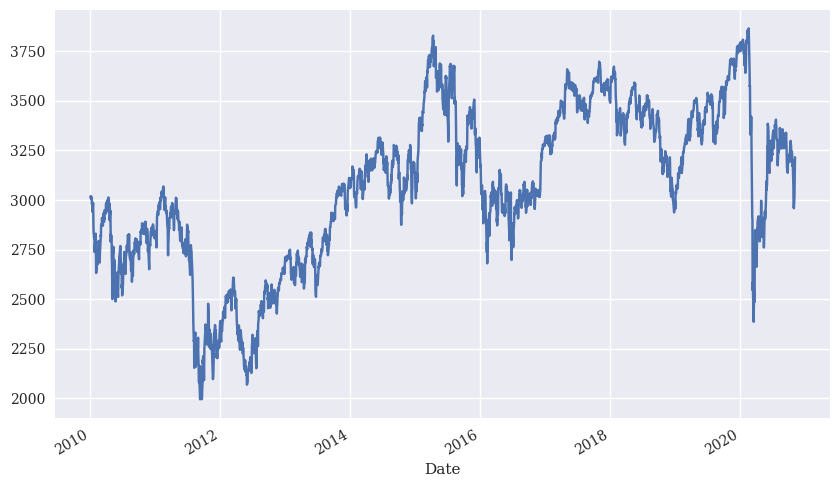

In [6]:
from pylab import mpl, plt
plt.style.use('seaborn-v0_8')
mpl.rcParams['font.family'] = 'serif'  # set serif font
data['.STOXX50E'].plot(grid=True, figsize=(10, 6));

<p style="font-family: monospace;">Historical EURO STOXX 50 index levels.

### VSTOXX Data

Second, visualizing the data from the same source as before for the VSTOXX index. The following figure visualizes the times series data for the main volatility index with symbol `.V2TX`. Inspection of the the figure reveals that the volatility index increases and even spikes when there are crises in the markets &mdash; which is best seen in the beginning of 2020.

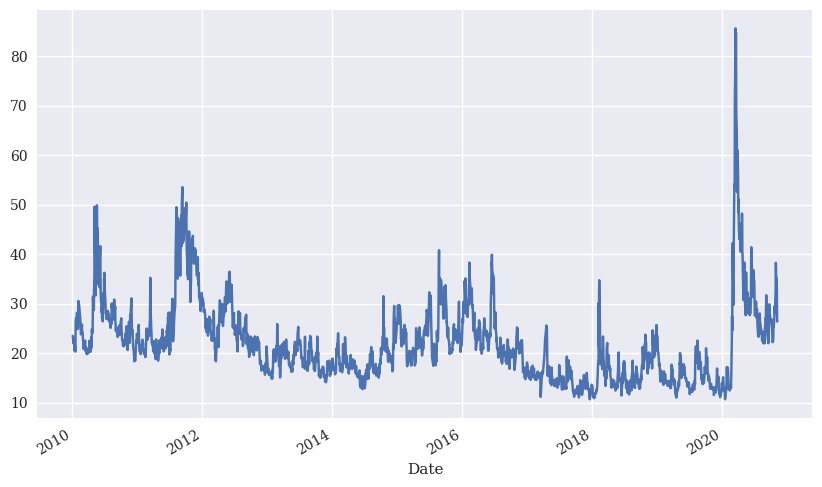

In [7]:
data['.V2TX'].plot(grid=True, figsize=(10, 6));

<p style="font-family: monospace;">Historical VSTOXX index levels.

## Basic Data Analysis

As illustrated in the appendix about _Introduction to Python_, pandas provides a wealth of options to analyze data stored in ``DataFrame`` objects. A sometimes helpful method is ``describe()`` which provides selected meta statistics for the single data sub-sets stored in ``DataFrame`` columns.

In [8]:
data.describe()

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX
count,2679.000000,2679.000000,2679.000000,2679.000000,2679.000000
mean,2055.569197,17.952019,93.416700,3064.280284,21.925272
std,655.146518,7.489060,15.536499,404.900818,8.049834
min,1022.580000,9.140000,61.760000,1995.010000,10.678300
25%,1408.610000,13.210000,83.390000,2782.080000,16.293400
50%,2046.610000,15.870000,90.640000,3076.050000,20.515800
75%,2638.210000,20.080000,100.155000,3405.910000,25.089900
max,3580.840000,82.690000,207.590000,3865.180000,85.620600


Sub-plots of multiple data sub-sets are easily generated with pandas. The result of the following plotting code is found in the following figure. 

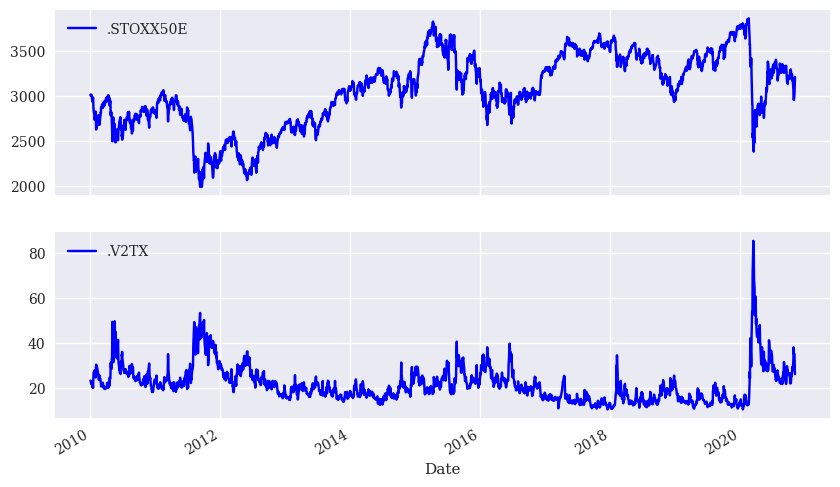

In [9]:
data[['.STOXX50E', '.V2TX']].plot(subplots=True,  # generate sub-plots per column
        figsize=(10, 6),  # sizing of the figure
        color='blue');  # color to plot the data

<p style="font-family: monospace;">Historical EURO STOXX 50 and VSTOXX index levels.

Similarly, you can visualize the absolute differences (over time) by using the ``diff()`` method and plotting them as a histogram (see the following the figure). 

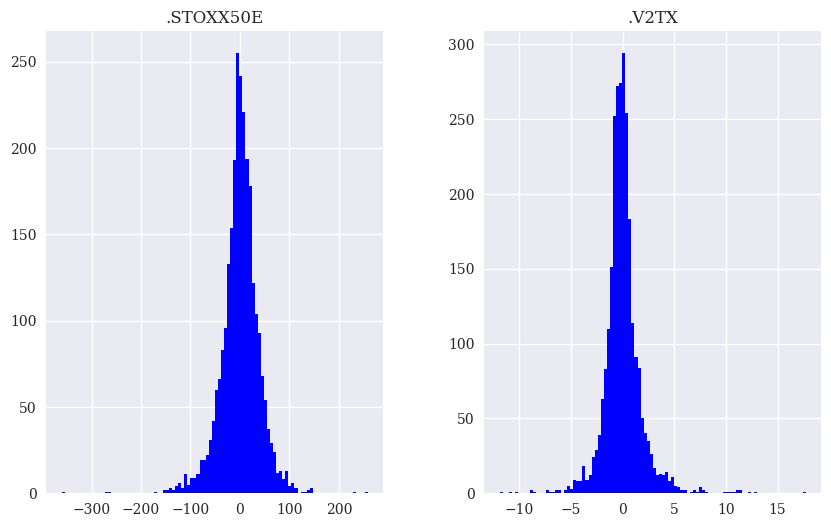

In [10]:
data[['.STOXX50E', '.V2TX']].diff().hist(figsize=(10, 6),  # figure sizing
                 color='blue',  # color for the plotted data
                 bins=100);  # number of bins to be used

<p style="font-family: monospace;">Histograms of historical absolute daily differences of EURO STOXX 50 and VSTOXX.

In similar spirit, we can calculate the relative or percent changes for the time series data.

In [11]:
data.pct_change().iloc[-10:]

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX
Date,,,,,
2020-10-23,0.003446,-0.019922,0.002867,0.008655,-0.028664
2020-10-26,-0.018590,0.178221,0.118883,-0.029264,0.127808
2020-10-27,-0.003026,0.027418,0.016832,-0.011159,0.030987
2020-10-28,-0.035288,0.207796,0.123337,-0.034866,0.168572
2020-10-29,0.011947,-0.066783,-0.027432,-0.001184,-0.018513
2020-10-30,-0.012130,0.011439,-0.017587,-0.000615,-0.058673
2020-11-02,0.012318,-0.023409,-0.017833,0.020732,-0.003231
2020-11-03,0.017799,-0.042553,-0.044655,0.026223,-0.070105
2020-11-04,0.022047,-0.168214,-0.103904,0.020121,-0.145307


The code to visualize this kind of result is the same as before (see the following figure).

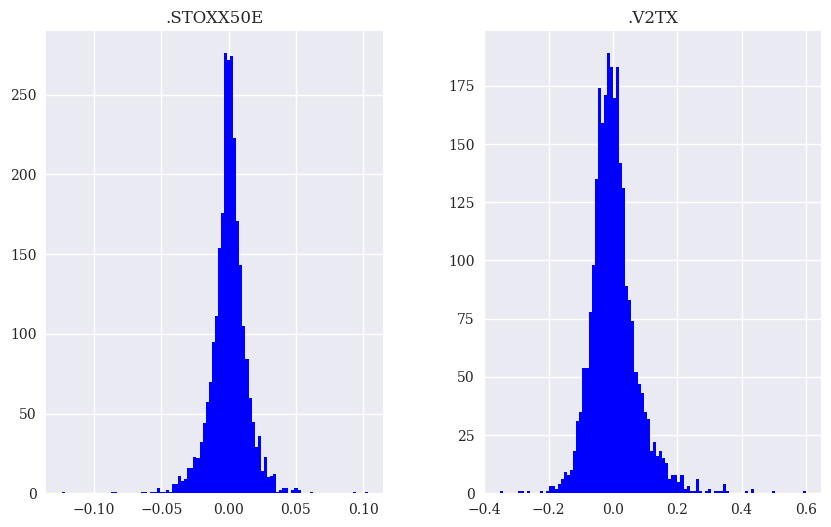

In [12]:
data[['.STOXX50E', '.V2TX']].pct_change().hist(figsize=(10, 6),
                       color='blue', 
                       bins=100);

<p style="font-family: monospace;">Histograms of historical percentage changes of EURO STOXX 50 and VSTOXX.

The majority of statistical analysis approaches relies on (log) returns and not on absolute time series data. The next few lines of code calculate the log returns for the two time series and stores them in yet another `DataFrame` object, called `log_rets`.

In [13]:
## fully vectorized calculation of log returns
log_rets = np.log(data / data.shift(1))
log_rets.iloc[:10]

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX
Date,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN
2010-01-05,0.003111,-0.035038,-0.040936,-0.001804,-0.016267
2010-01-06,0.000545,-0.009868,-0.039278,-0.000897,-0.006892
2010-01-07,0.003993,-0.005233,-0.007418,-0.000771,-0.012288
2010-01-08,0.002878,-0.050024,-0.021678,0.003489,-0.032194
2010-01-11,0.001745,-0.032514,-0.012866,-0.002525,0.033713
2010-01-12,-0.009425,0.039111,0.082092,-0.011141,0.008486
2010-01-13,0.008291,-0.022162,0.070053,0.000510,-0.013877
2010-01-14,0.002424,-0.012402,-0.013462,0.003787,-0.095442


The following figure visualizes the log returns times series for both the EURO STOXX 50 and VSTOXX indexes.

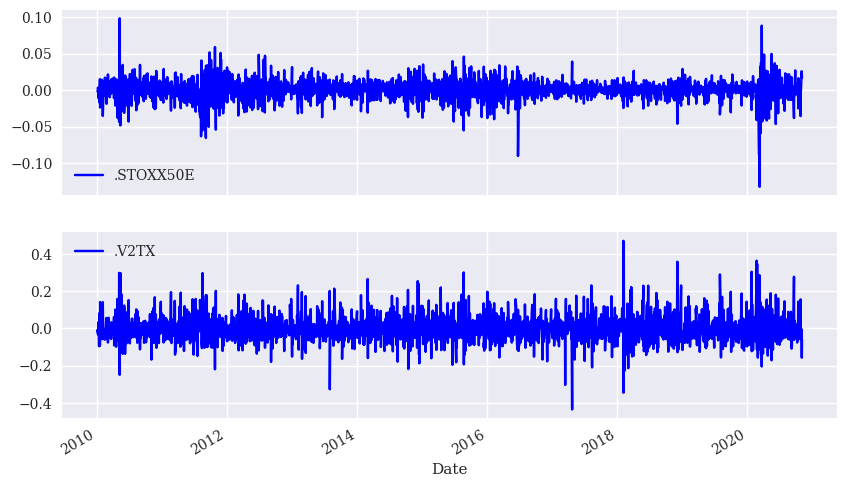

In [14]:
log_rets[['.STOXX50E', '.V2TX']].plot(subplots=True,
              figsize=(10, 6),
              color='blue',
              grid=True);

<p style="font-family: monospace;">Log returns of EURO STOXX 50 and VSTOXX over time.

## Correlation Analysis

Equipped with the log returns, a thorough investigation of the correlation between the EURO STOXX 50 and VSTOXX indexes is straightforward. For example, pandas provides the ``corr()`` method to calculate correlations between time series data stored in different ``DataFrame`` columns.

In [15]:
log_rets.corr()

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX
.SPX,1.000000,-0.757955,-0.596050,0.646590,-0.491849
.VIX,-0.757955,1.000000,0.830883,-0.514712,0.564040
.VVIX,-0.596050,0.830883,1.000000,-0.402470,0.457772
.STOXX50E,0.646590,-0.514712,-0.402470,1.000000,-0.753425
.V2TX,-0.491849,0.564040,0.457772,-0.753425,1.000000


Similar results are obtained by calculating the correlation of the data stored in one pandas `Series` object with another data set in another `Series` object. 

In [16]:
log_rets['.STOXX50E'].corr(log_rets['.V2TX'])

-0.7534248198796238

The ``plot()`` method of pandas ``DataFrame`` objects knows different types of plots. For example, scatter plots are helpful to visualize return data of two different time series (see the following figure).

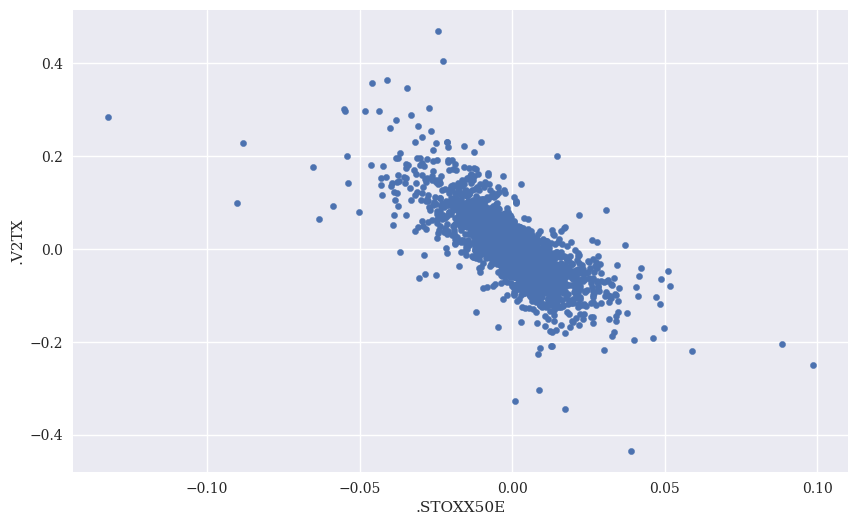

In [17]:
## plot log returns as scatter plot
log_rets.plot(x='.STOXX50E', y='.V2TX',
              kind='scatter', figsize=(10, 6));

<p style="font-family: monospace;">Scatter plot of log returns of EURO STOXX 50 and VSTOXX.

The following figure adds the time dimension to the data through coloring to illustrate the relation between the two time series over time (during different "regimes").

<Figure size 800x550 with 0 Axes>

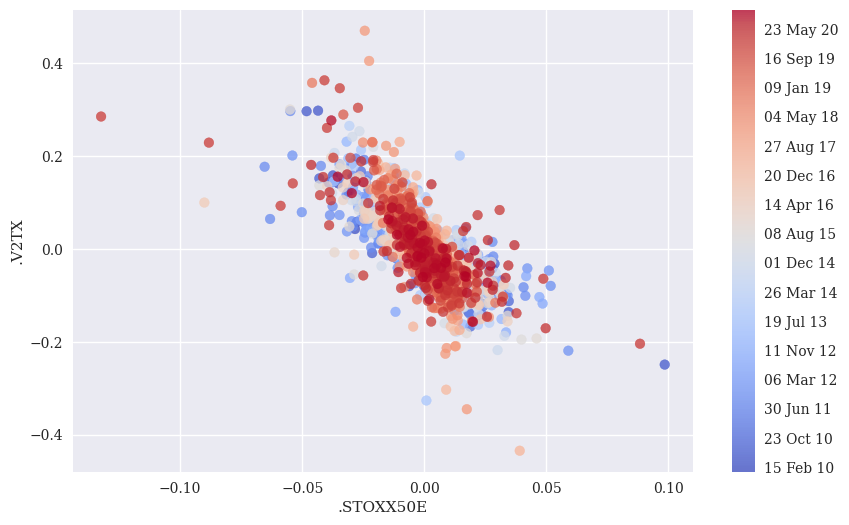

In [18]:
log_rets = log_rets.dropna() # delete NaN values
plt.set_cmap('coolwarm');  # set color map
mpl_dates = mpl.dates.date2num(log_rets.index.to_pydatetime())  # conversion
plt.figure(figsize=(10, 6))
plt.scatter(log_rets['.STOXX50E'], log_rets['.V2TX'],
            c=mpl_dates, marker='o', alpha=0.75)  # the actual plot
plt.xlabel('.STOXX50E')
plt.ylabel('.V2TX')
plt.colorbar(ticks=mpl.dates.DayLocator(interval=250),  # adding bar
        format=mpl.dates.DateFormatter('%d %b %y')); 

<p style="font-family: monospace;">Scatter plot of log returns of EURO STOXX 50 and VSTOXX with dates.

Although the negative correlation between the two indexes is almost evident from the previous two figures, let us formally calculate and represent the negative correlation by a linear regression line.The following figure adds such a regression line to the raw log returns in the scatter plot. Negative correlation translates into a negative slope of the regression line.

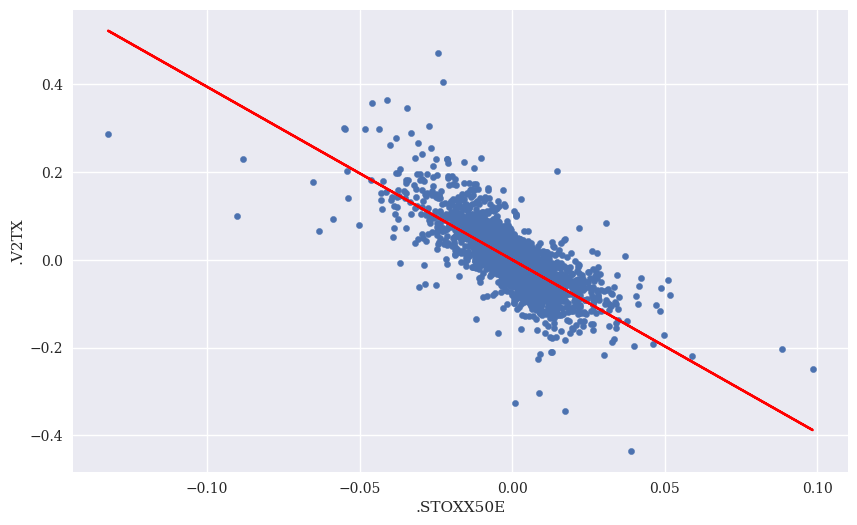

In [19]:
## conduct linear regression
p = np.polyfit(log_rets['.STOXX50E'].values,
               log_rets['.V2TX'].values,
               deg=1)  # the regression
log_rets.plot(x='.STOXX50E', y='.V2TX',
              kind='scatter', figsize=(10, 6));  # the actual plotting
## plot the regression line
plt.plot(log_rets['.STOXX50E'], np.polyval(p, log_rets['.STOXX50E']),
         'r');  # adding the regression line

<p style="font-family: monospace;">Scatter plot of log returns of EURO STOXX 50 and VSTOXX with regression line.

The seaborn plotting library is specifically developed with statistical applications in mind. It therefore provides multiple useful, high level plotting capabilities. One of the them is the ``jointplot()`` function. The result of applying this function to the log return data is displayed in the following figure. For sure the richest and most insightful presentation so far for our purposes.

In [20]:
import seaborn as sns

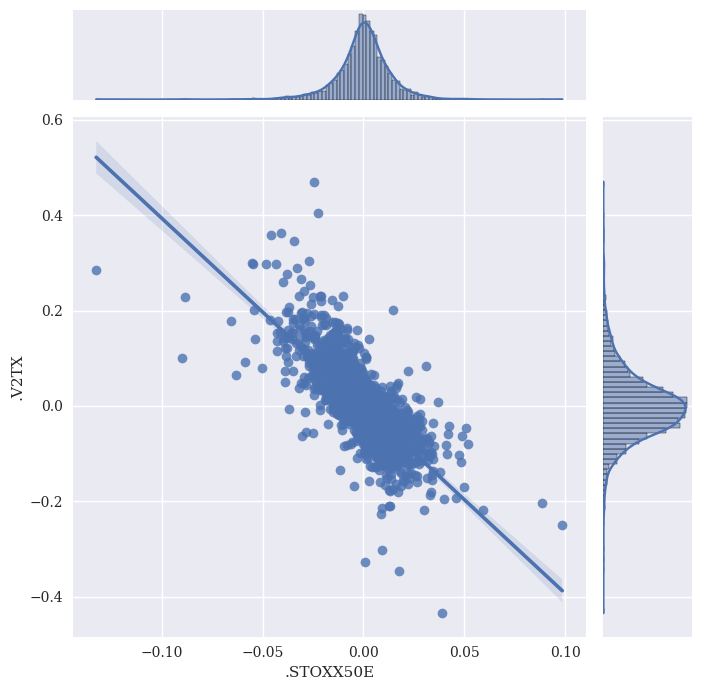

In [21]:
sns.jointplot(x=log_rets['.STOXX50E'], y=log_rets['.V2TX'], 
              kind='reg', height=7);

<p style="font-family: monospace;">Scatter plot of log returns of EURO STOXX 50 and VSTOXX with regression line and histograms.

The final analysis in this section considers correlation *over time*. To this end, pandas provides the ``rolling()`` method which allows, among otherts, the vectorized calculation of correlation for moving time windows via ``corr()``. We chose a window size of 252 trading days which represents roughly one year.

In [22]:
data['CORR'] = log_rets['.STOXX50E'].rolling(
                window=252).corr(log_rets['.V2TX'])

The following figure shows the rolling correlation data and illustrates well that correlation fluctuates for different yearly windows but that it is negative for any chosen yearly window.

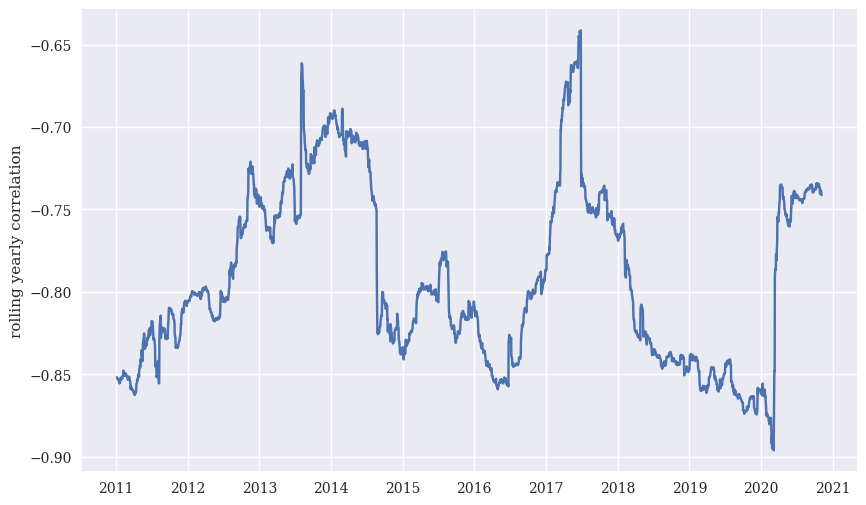

In [23]:
to_plot = data.dropna()  # drop NaN values
plt.figure(figsize=(10, 6))
plt.plot(data.index, data.CORR)
plt.ylabel('rolling yearly correlation');

<p style="font-family: monospace;">Rolling yearly correlation of EURO STOXX 50 and VSTOXX.

## Constant Proportion Investment Strategies

One way to make use of the fact that the VSTOXX index is negatively correlated with the EURO STOXX 50 index is to implement a *constant proportion investment strategy*. Respective results are found, for example, in the study by Guobuzaite and Martellini (2012). Basically, a constant (dollar) proportion investment strategy keeps the proportion of money invested in securities of a portfolio over time constant by dynamic re-balancings given the movements in the prices of the single securities.

In the example of this section, we assume that direct investments both in the EURO STOXX 50 and the VSTOXX indexes are possible and that no transaction costs apply. Although this might not be realistic, it simplifies the anaylsis and illustrates the basic idea pretty well.

To begin with, let us adjust the origingal data sets for the EURO STOXX 50 and VSTOXX indexes by mainly normalizing both time series to starting values of 100.

In [24]:
del data['CORR']  # delete correlation data
data = data.dropna()  # drop NaN values
data = data / data.iloc[0] * 100  # normalization

In [25]:
data.head()

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX
Date,,,,,
2010-01-04,100.000000,100.000000,100.000000,100.000000,100.000000
2010-01-05,100.311565,96.556886,95.989086,99.819736,98.386466
2010-01-06,100.366287,95.608782,92.291951,99.730267,97.710687
2010-01-07,100.767880,95.109780,91.609823,99.653390,96.517335
2010-01-08,101.058262,90.469062,89.645293,100.001657,93.459530


First, we analyze a typical *passive investment strategy* allocating 30% of a portfolio to the VSTOXX index and the remaining 70% to the EURO STOXX 50.

In [26]:
invest = 100  # initial investment
cratio = 0.3  # VSTOXX ratio in the beginning
## number of EURO STOXX (fictional) securities
data['Equity'] = (1 - cratio) * invest / data['.STOXX50E'][0]
## number of VSTOXX (fictional) securities
data['Volatility'] = cratio * invest / data['.V2TX'][0]

/var/folders/l2/c_yy_yhn7kg_m0qzhnr7yf7r0000gp/T/ipykernel_14536/1910015756.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data['Equity'] = (1 - cratio) * invest / data['.STOXX50E'][0]
/var/folders/l2/c_yy_yhn7kg_m0qzhnr7yf7r0000gp/T/ipykernel_14536/1910015756.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data['Volatility'] = cratio * invest / data['.V2TX'][0]


In vectorized fashion, we calculate next the absolute values of such a portfolio over time, i.e. as a time series.

In [27]:
data['Passive'] = (data['Equity'] * data['.STOXX50E']
                + data['Volatility'] * data['.V2TX'])

The following figure illustrates the performance of this particular passive investment strategy in comparison to a passive strategy purely investing in the EURO STOXX 50 index. In times of crises, for example at the beginning of 2020, the strategy peforms better. However, over the whole period there is hardly a difference in the end result.  

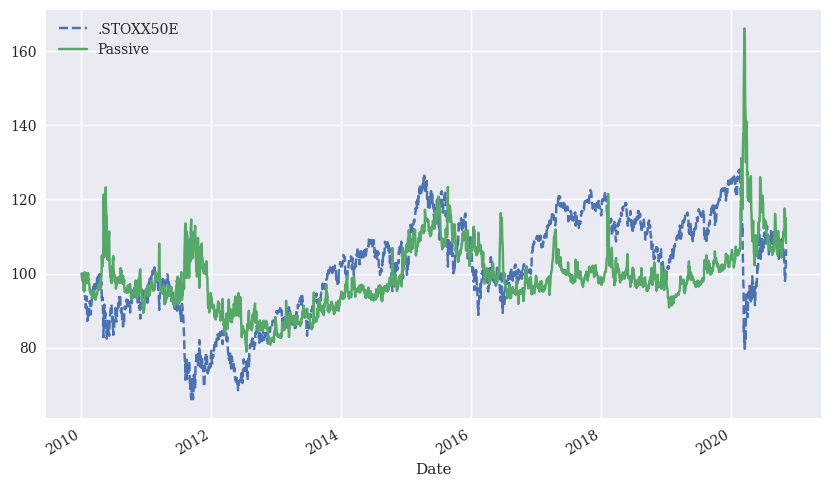

In [28]:
data[['.STOXX50E', 'Passive']].plot(figsize=(10, 6), style=['--', '-']);

<p style="font-family: monospace;">Passive investment strategy (hypothetical) with EURO STOXX 50 and VSTOXX.

Second, the *active constant proportion investment strategy*, which keeps the dollar proportion invested in the VSTOXX index constant at 30% *over time* through daily re-balancings of the portfolio. In this case, the single calculations are done step-by-step through looping over the single historical trading dates.

In [29]:
for i in range(1, len(data)):  # daily re-balancing
    evalue = data['Equity'].iloc[i - 1] * data['.STOXX50E'].iloc[i]
    vvalue = data['Volatility'].iloc[i - 1] * data['.V2TX'].iloc[i]
    tvalue = evalue + vvalue  # total wealth  
    data.loc[data.index[i], 'Equity'] = (1 - cratio) * tvalue / data['.STOXX50E'].iloc[i] 
    data.loc[data.index[i], 'Volatility'] = cratio * tvalue / data['.V2TX'].iloc[i] 

Based on the results, we calculate the  absolute performance of this active strategy as before. Over the first few trading days no major performance differences arise.

In [30]:
data['Active'] = (data['Equity'] * data['.STOXX50E']
                + data['Volatility'] * data['.V2TX'])
np.round(data.head(), 2)

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX,Equity,Volatility,Passive,Active
Date,,,,,,,,,
2010-01-04,100.00,100.00,100.00,100.00,100.00,0.70,0.30,100.00,100.00
2010-01-05,100.31,96.56,95.99,99.82,98.39,0.70,0.30,99.39,99.39
2010-01-06,100.37,95.61,92.29,99.73,97.71,0.70,0.30,99.12,99.12
2010-01-07,100.77,95.11,91.61,99.65,96.52,0.69,0.31,98.71,98.71
2010-01-08,101.06,90.47,89.65,100.00,93.46,0.69,0.31,98.04,98.01


Over the whole time period, however, the active strategy &mdash; showing a 600+ percent gain &mdash; significantly outperforms the passive one.

In [31]:
np.round(data.tail(), 2)

,.SPX,.VIX,.VVIX,.STOXX50E,.V2TX,Equity,Volatility,Passive,Active
Date,,,,,,,,,
2020-10-30,288.61,189.72,198.14,98.03,150.33,5.16,1.44,113.72,722.32
2020-11-02,292.17,185.28,194.61,100.06,149.84,5.12,1.47,114.99,732.11
2020-11-03,297.37,177.40,185.92,102.68,139.34,4.98,1.57,113.68,730.15
2020-11-04,303.93,147.55,166.60,104.75,119.09,4.74,1.79,109.05,708.60
2020-11-05,309.84,137.62,160.55,106.55,112.16,4.63,1.89,108.23,704.78


Let us briefly verify whether the above implementation indeed yields constant proportions for the two (fictional) securities in the portfolio.

In [32]:
(data['Volatility'] * data['.V2TX'] / data['Active'])[:5]

Date
2010-01-04    0.3
2010-01-05    0.3
2010-01-06    0.3
2010-01-07    0.3
2010-01-08    0.3
dtype: float64

In [33]:
(data['Equity'] * data['.STOXX50E'] / data['Active'])[:5]

Date
2010-01-04    0.7
2010-01-05    0.7
2010-01-06    0.7
2010-01-07    0.7
2010-01-08    0.7
dtype: float64

Being assured that we indeed have implemented a constant proportion trading strategy, have a look at the following figure which impressively illustrates the outperformance of the active approach over a passive investment in the stock index itself. However, keep in mind that all this rests on a number of simplifying assumptions.

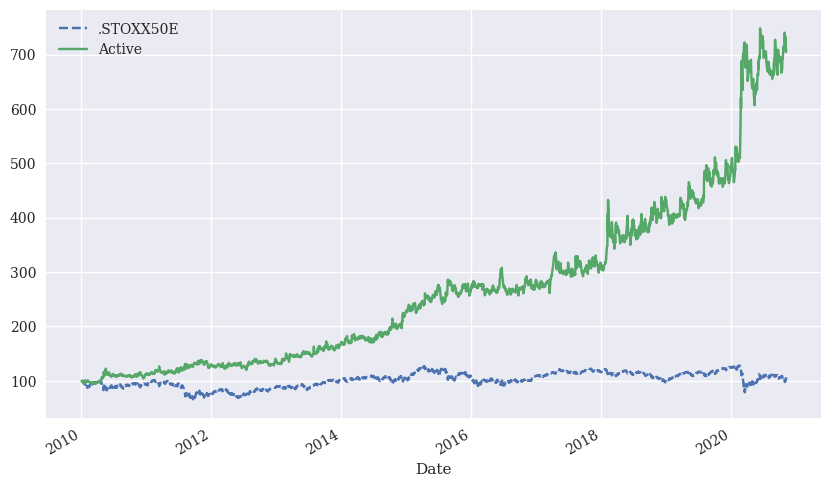

In [34]:
data[['.STOXX50E', 'Active']].plot(figsize=(10, 6), style=['--', '-']);

<p style="font-family: monospace;">Active, constant proportion investment strategy (hypothetical) with EURO STOXX 50 and VSTOXX.

The assumption of 30% invested in the VSTOXX index might seem a bit ad hoc. Therefore, the following derives the optimal allocation for the given time period and data sets by a brute force approach. First, we clean up the ``DataFrame`` object to reduce it again to the original time series data for the two indexes.

In [35]:
## re-initialize DataFrame
data = data[['.STOXX50E', '.V2TX']]
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2679 entries, 2010-01-04 to 2020-11-05
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   .STOXX50E  2679 non-null   float64
 1   .V2TX      2679 non-null   float64
dtypes: float64(2)
memory usage: 127.3 KB


The function below calculates the performance of a constant proportion investment strategy for different VSTOXX dollar proportions and different starting and ending dates (both defaulting to the data sets' start and end dates).

In [36]:
from copy import deepcopy
def vstoxx_strategy(cratio, start=data.index[0], end=data.index[-1]):
    base = deepcopy(data[(data.index >= start) & (data.index <= end)])
    invest = 100  # initial invest
    base['Equity'] = (1 - cratio) * invest / base['.STOXX50E'].iloc[0]
    base['Volatility'] = cratio * invest / base['.V2TX'].iloc[0]
    for i in range(1, len(base)):  # daily re-balancing
        evalue = base['Equity'].iloc[i - 1] * base['.STOXX50E'].iloc[i]
        vvalue = base['Volatility'].iloc[i - 1] * base['.V2TX'].iloc[i]
        tvalue = evalue + vvalue
        base.loc[base.index[i], 'Equity'] = (1 - cratio) * tvalue / base['.STOXX50E'].iloc[i]
        base.loc[base.index[i], 'Volatility'] = cratio * tvalue / base['.V2TX'].iloc[i]
    base['Active'] = (base['Equity'] * base['.STOXX50E']
                + base['Volatility'] * base['.V2TX'])  # wealth position
    print('A con. VSTOXX ratio of %.2f yields a net perform. of %6.1f%%.' \
            % (cratio, (base['Active'].iloc[-1] / base['Active'].iloc[0] - 1) * 100))

Equipped with this function, let us calculate the net perfomance for a VSTOXX dollar ratio of 30% as before.

In [37]:
vstoxx_strategy(0.3)

A con. VSTOXX ratio of 0.30 yields a net perform. of  604.8%.


We do the same for 40% which obviously yields an even better result.

In [38]:
vstoxx_strategy(0.4)

A con. VSTOXX ratio of 0.40 yields a net perform. of  817.9%.


Applying an approach which is a bit more systematic, we get the following results for different constant dollar proportion assumptions. Over the whole period for which data is available a 50%:50% investment strategy seems to be optimal with a net performance of more than 900%.

In [39]:
for cratio in np.arange(0, 1.01, 0.1):
    vstoxx_strategy(cratio)

A con. VSTOXX ratio of 0.00 yields a net perform. of    6.6%.


A con. VSTOXX ratio of 0.10 yields a net perform. of  140.9%.


A con. VSTOXX ratio of 0.20 yields a net perform. of  351.7%.


A con. VSTOXX ratio of 0.30 yields a net perform. of  604.8%.


A con. VSTOXX ratio of 0.40 yields a net perform. of  817.9%.


...

A con. VSTOXX ratio of 0.60 yields a net perform. of  814.0%.


A con. VSTOXX ratio of 0.70 yields a net perform. of  601.3%.


A con. VSTOXX ratio of 0.80 yields a net perform. of  352.4%.


A con. VSTOXX ratio of 0.90 yields a net perform. of  145.5%.


A con. VSTOXX ratio of 1.00 yields a net perform. of   12.2%.


Let us implement the same analysis for the time period beginning in January 2017 and ending with the second quarter of 2020. In this case, a constant dollar proportion invested in the VSTOXX of about 60% seems optimal and yields a net performance of about 220%.

In [40]:
for cratio in np.arange(0, 1.01, 0.1):
    vstoxx_strategy(cratio, start='2017-1-1', end='2020-7-1')

A con. VSTOXX ratio of 0.00 yields a net perform. of   -2.6%.


A con. VSTOXX ratio of 0.10 yields a net perform. of   43.1%.


A con. VSTOXX ratio of 0.20 yields a net perform. of   94.7%.


A con. VSTOXX ratio of 0.30 yields a net perform. of  145.9%.


A con. VSTOXX ratio of 0.40 yields a net perform. of  188.6%.


...

A con. VSTOXX ratio of 0.60 yields a net perform. of  221.3%.


A con. VSTOXX ratio of 0.70 yields a net perform. of  205.4%.


A con. VSTOXX ratio of 0.80 yields a net perform. of  170.9%.


A con. VSTOXX ratio of 0.90 yields a net perform. of  124.4%.


A con. VSTOXX ratio of 1.00 yields a net perform. of   73.6%.


In [41]:
for cratio in np.arange(0, 1.01, 0.1):
    vstoxx_strategy(cratio, start='2019-7-1', end='2020-10-31')

A con. VSTOXX ratio of 0.00 yields a net perform. of  -15.4%.
A con. VSTOXX ratio of 0.10 yields a net perform. of   10.8%.


A con. VSTOXX ratio of 0.20 yields a net perform. of   40.1%.
A con. VSTOXX ratio of 0.30 yields a net perform. of   71.1%.


A con. VSTOXX ratio of 0.40 yields a net perform. of  102.1%.


A con. VSTOXX ratio of 0.50 yields a net perform. of  131.2%.
A con. VSTOXX ratio of 0.60 yields a net perform. of  156.2%.


A con. VSTOXX ratio of 0.70 yields a net perform. of  175.2%.
A con. VSTOXX ratio of 0.80 yields a net perform. of  186.9%.


A con. VSTOXX ratio of 0.90 yields a net perform. of  190.4%.


A con. VSTOXX ratio of 1.00 yields a net perform. of  185.4%.


## Conclusions

This chapter is about the retrieval and analysis of EURO STOXX 50 and VSTOXX historical data. It shows how to use Python and pandas to retrieve historical data sets with pandas. It also shows how to implement Python code to replicate central stylized facts about stock and volatility indexes, namely their highly negative correlation and the benefits of constant (dollar) proportion investment strategies involving (products based on) equity and volatility indexes.

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:team@tpq.io">team@tpq.io</a>